# Run adaptive immune system with noisy pMHCs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

import multiprocessing as mp
from tqdm import tqdm
from joblib import Parallel, delayed
import os
from sklearn.feature_selection import mutual_info_classif
from stoch_sim_model import *
from joint_plot_grid_nb import *
import seaborn as sns

plt.style.use('/Users/ObinnaUkogu/Desktop/custom.mplstyle')
%config InlineBackend.figure_format = 'retina'

### (1) Plot sample trajectory

[0.5 0.5 0.1 0.1]


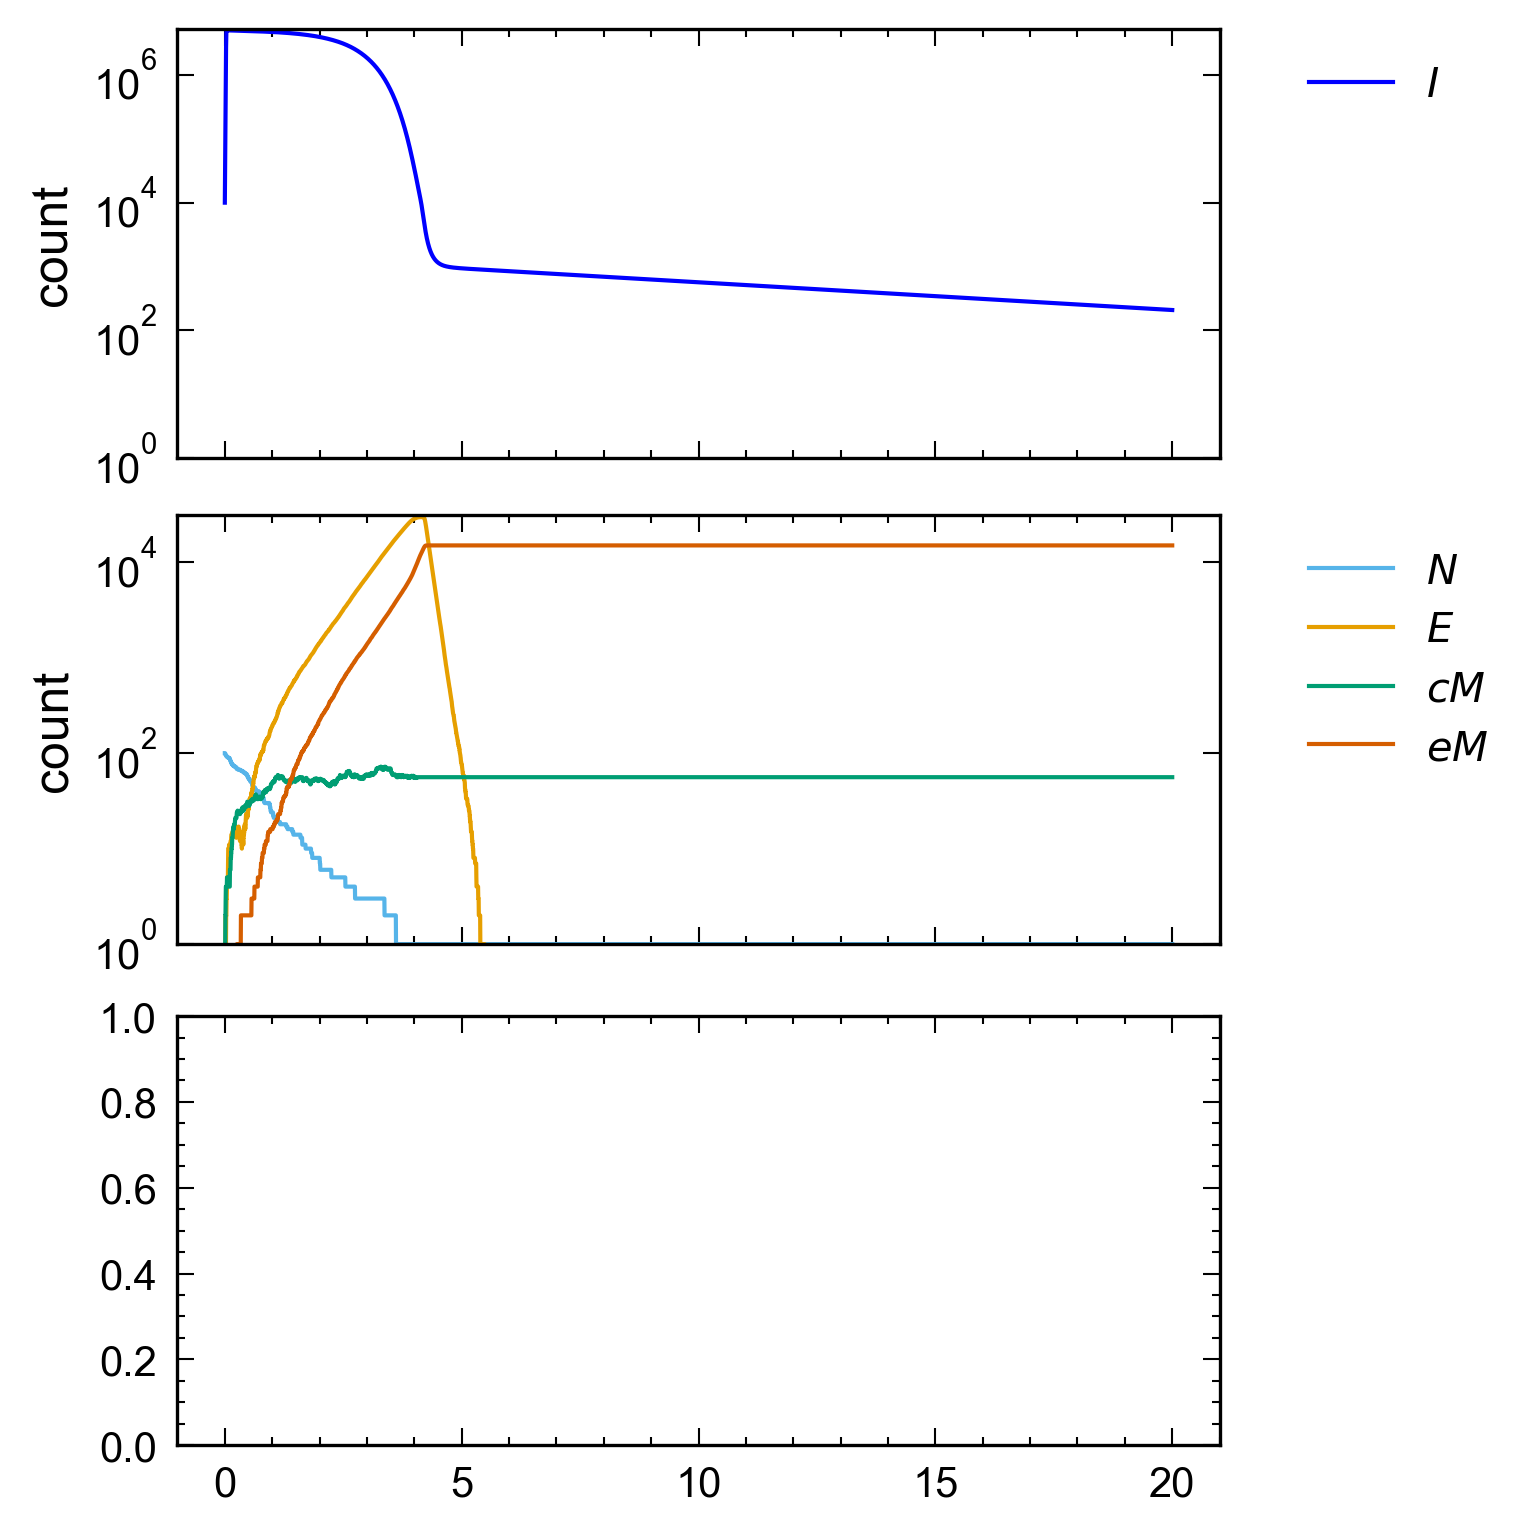

In [2]:
# Plot outputs
I_0 = 10000
b_I = 0.00003
t1 = 10
d_IE = 3.8*10**(-4)
T_I = 2

infection_type = "prim" #"prim"

# rates, I, N, E, cM, eM, T, ts = stoch_sim(I_0, b_I, t1, d_IE, 
#                                     noise_model = "pop", 
#                                     noise_cv = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
#                                     infection = infection_type)

regs, I, N, E, cM, eM, T, ts = agent_stoch_sim(I_0 = I_0, b_I = b_I, t1 = t1, d_IE = d_IE, T_I = T_I,
                    regulation_coeffs = [psi_N_I, psi_cM_I, psi_E_I, psi_E_c],
                    infection = "prim")

fig, (ax1, ax2, ax3) = plt.subplots(3, dpi = 150, constrained_layout=True, sharex = True, figsize=(5,5))
#ax1.plot(ts, I/a2, 'b', label = r'$\frac{a_1}{a_2}$')
ax1.plot(ts, I, 'b', label = r'$I$')
ax1.set(ylabel='count')
ax1.set_ylim(1,)
ax1.semilogy()
ax1.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

ax2.plot(ts, N, label = r'$N$')
ax2.plot(ts, E, label = r'$E$')
ax2.plot(ts, cM, label = r'$cM$')
ax2.plot(ts, eM, label = r'$eM$')
ax2.set(ylabel='count')
ax2.set_ylim(1,)
ax2.semilogy()
ax2.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

#ax3.plot(ts, c1_ss.py_func(t1,I, E, T),'k-', label = r'$c_1$')
#ax3.plot(ts, c1_ss(P1.py_func(I, E)[0], E, T)/k_E,'k-', label = r'$\frac{c_1}{k_E}$')
#ax3.plot(ts, c2_ss(I,E),'k-.', label = r'$c_2$')
# ax3.set(xlabel=r'time, $t$ (days)', ylabel='count')
# ax3.semilogy()
# ax3.set_ylim(1,)
# ax3.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

fig.savefig(infection_type+'-'+'virus-effector dynamics.pdf', dpi=300, bbox_inches="tight")
print(regs)

(100, 5, 10001)


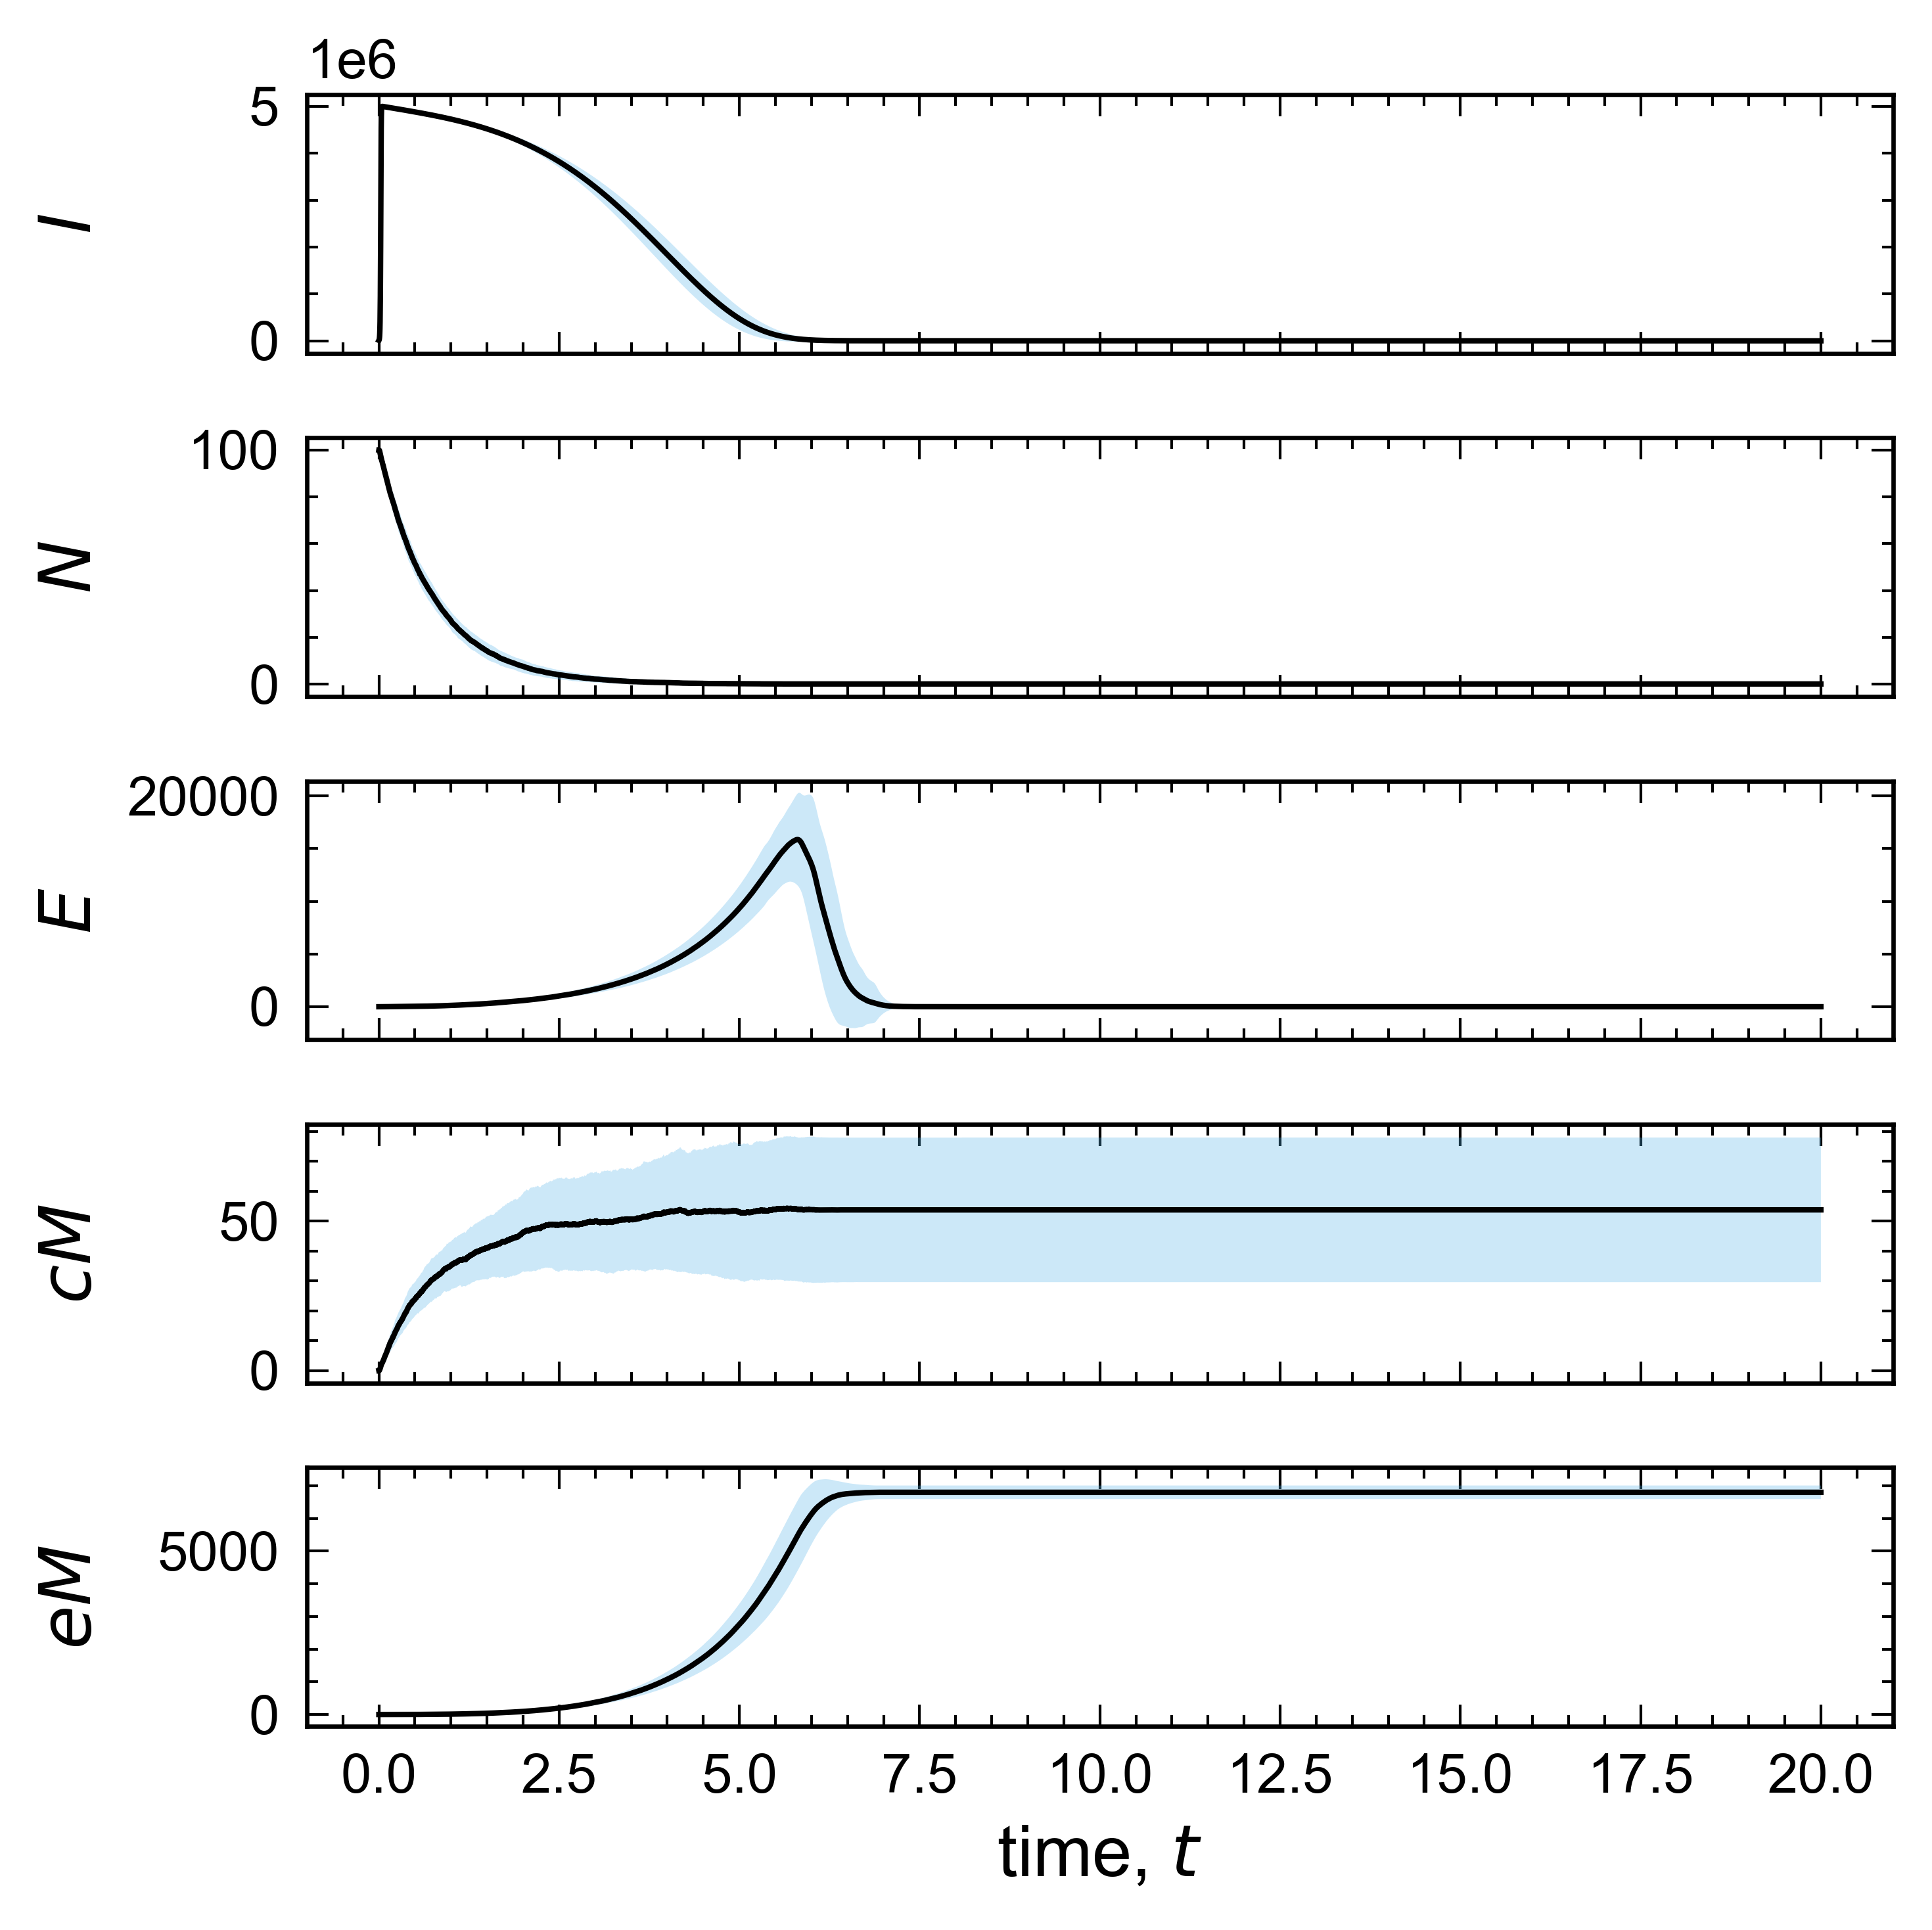

In [3]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(5,5), sharex=True, dpi=300)

# This sets how many simulations are performed.
num_realizations = 100
plot_labels = [r"$I$", r"$N$", r"$E$", r"$cM$", r"$eM$"]

trajectories = np.zeros(shape=(num_realizations, 5, steps+1))
for idx in range(num_realizations):
    _, I, N, E, cM, eM, T, ts = agent_stoch_sim(infection = infection_type)

    trajectories[idx] = I, N, E, cM, eM
print(trajectories.shape)
# Filter out the entries in the numpy array which were full of zeros
# so they aren't plotted.
where_nonzero = np.count_nonzero(trajectories, axis=2).sum(axis=1) != 0
trajectories = trajectories[where_nonzero]

# Compute the mean and standard deviation over all the rows at each column.
# Plot the mean as a solid line and the mean +/- std as fill.
for states, ax in enumerate(axes):
    means = np.mean(trajectories[:,states,:], axis=0)
    stds = np.std(trajectories[:,states,:], axis=0)
    ax.plot(ts, means, 'k-')
    #ax.semilogy()
    ax.fill_between(ts, means - stds, means + stds, alpha=0.3)

# Make legend appear.
# for ax in axes:
#     ax.legend(fontsize=11, frameon=False, loc='upper right') #, bbox_to_anchor=(1.0,0.5))    

# Set xlabel.
for states, ax in enumerate(axes):
    if states == 4:
        ax.set_xlabel('time, $t$', fontsize=13)
    
# Set ylabels.
ylabels = plot_labels
for ax, ylabel in zip(axes, ylabels):
    ax.set_ylabel(ylabel, fontsize=13)

# Align y-axis labels.
fig.align_ylabels(axes)

fig.tight_layout()
plt.show()
fig.savefig(infection_type+'-'+'population-virus-effector dynamics.pdf', dpi=300, bbox_inches="tight")

## (2) Parallelize simulation runs

In [3]:
# Parallelize simulation runs

# def for_parallel(I_0, b_I, t1, d_IE, 
#                  noise_cv = [0.05, 0.0, 0.0, 0.0, 0.0, 0.0]):
    
#     return sum_sim(I_0, b_I, t1, d_IE, noise_cv = noise_cv, infection = infection_type)
def for_parallel(I_0, b_I, t1, d_IE):
    
    return sum_sim(I_0, b_I, t1, d_IE, infection = infection_type)

In [4]:
# Set global simulation parameters
runs = 1000

In [5]:
# run several simulations varying b_I
cv_b_I = 2
#b_Is = np.random.uniform(0.1*b_I, 10*b_I, size = runs) 
b_Is = np.random.lognormal(mean = np.log(b_I/np.sqrt(1 + cv_b_I**2)), 
                            sigma = np.sqrt(np.log(1 + cv_b_I**2)), size = runs)
t1s = [t1]
d_IEs = [d_IE]
T_Is = [T_I]
I_0s = [I_0]

run_data_b_I = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(b_Is)/8))(delayed(for_parallel)(I_0, b_I, t1, d_IE)
                                              for I_0 in I_0s
                                              for b_I in b_Is
                                              for t1 in t1s
                                              for d_IE in d_IEs))

/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:282: RuntimeWarning: divide by zero encountered in true_divide
  N_act = (np.random.exponential(1/g_N(t1,I[i-1], E_pop, Treg0, max_val = div_rates[0,:]), N0) < dt)*N_m[i-1,:]
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:282: RuntimeWarning: divide by zero encountered in true_divide
  N_act = (np.random.exponential(1/g_N(t1,I[i-1], E_pop, Treg0, max_val = div_rates[0,:]), N0) < dt)*N_m[i-1,:]
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:282: RuntimeWarning: divide by zero encountered in true_divide
  N_act = (np.random.exponential(1/g_N(t1,I[i-1], E_pop, Treg0, max_val = div_ra

In [6]:
# run several simulations varying t1
cv_t1 = 0.5

b_Is = [b_I] #np.abs(np.random.normal(loc = mu_b_I, scale = mu_b_I, size = runs))
#t1s = np.random.uniform(t1, 2*t1, size = runs) 
t1s = np.random.lognormal(mean = np.log(t1/np.sqrt(1 + cv_t1**2)), 
                            sigma = np.sqrt(np.log(1 + cv_t1**2)), size = runs)
d_IEs = [d_IE]
T_Is = [T_I]
I_0s = [I_0]

run_data_t1 = np.nan_to_num(np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(t1s)/8))(delayed(for_parallel)(I_0, b_I, t1, d_IE)
                                              for I_0 in I_0s                                                  
                                              for b_I in b_Is
                                              for t1 in t1s
                                              for d_IE in d_IEs)))

/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:332: RuntimeWarning: invalid value encountered in double_scalars
  np.where(np.argmax(E) < 1, 0.0, np.max(E)/(np.argmax(E)*dt)), \
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:333: RuntimeWarning: divide by zero encountered in double_scalars
  np.argmax(E)*dt, np.where(np.max(E) < 1.0, 0.0, (eM[-1]+cM[-1])/np.max(E)), np.sum(E*dt), np.sum(np.log(np.maximum(E, E_min))*dt),\
/Users/ObinnaUkogu/Documents/Academics/University of Washington/Research Projects/Armita Group/immunology/maximizing information flow/code/infoimmune/stoch_sim_model.py:332: RuntimeWarning: invalid value encountered in double_scalars
  np.where(np.argmax(E) < 1, 0.0, np.max(E)/(np.argmax(E)*dt)), \
/Users/ObinnaUkogu/Documents/Ac

In [7]:
# run several simulations varying d_IE
cv_d_IE = 2

b_Is = [b_I] #np.abs(np.random.normal(loc = mu_b_I, scale = mu_b_I, size = runs))
#d_IEs = np.random.uniform(0.1*d_IE, 10*d_IE, size = runs) 
t1s = [t1]
d_IEs = np.random.lognormal(mean = np.log(d_IE/np.sqrt(1 + cv_d_IE**2)), 
                            sigma = np.sqrt(np.log(1 + cv_d_IE**2)), size = runs)
T_Is = [T_I]
I_0s = [I_0]

run_data_d_IE = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(d_IEs)/8))(delayed(for_parallel)(I_0, b_I, t1, d_IE)
                                              for I_0 in I_0s
                                              for b_I in b_Is
                                              for t1 in t1s
                                              for d_IE in d_IEs))

In [8]:
# run several simulations varying I_0
cv_I_0 = 5

b_Is = [b_I]
T_Is = [T_I]
#I_0s = np.random.uniform(I_0, 100*I_0, size = runs) 
t1s = [t1]
d_IEs = [d_IE]
I_0s = np.random.lognormal(mean = np.log(I_0/np.sqrt(1 + cv_I_0**2)), 
                            sigma = np.sqrt(np.log(1 + cv_I_0**2)), size = runs)

run_data_I_0 = np.array(Parallel(n_jobs=os.cpu_count(), batch_size=int(len(I_0s)/8))(delayed(for_parallel)(I_0, b_I, t1, d_IE)
                                              for I_0 in I_0s
                                              for b_I in b_Is
                                              for t1 in t1s
                                              for d_IE in d_IEs))

## (3) Plot distribution of response statistics from simulations varying $b_{a_1}$ and $t_1$

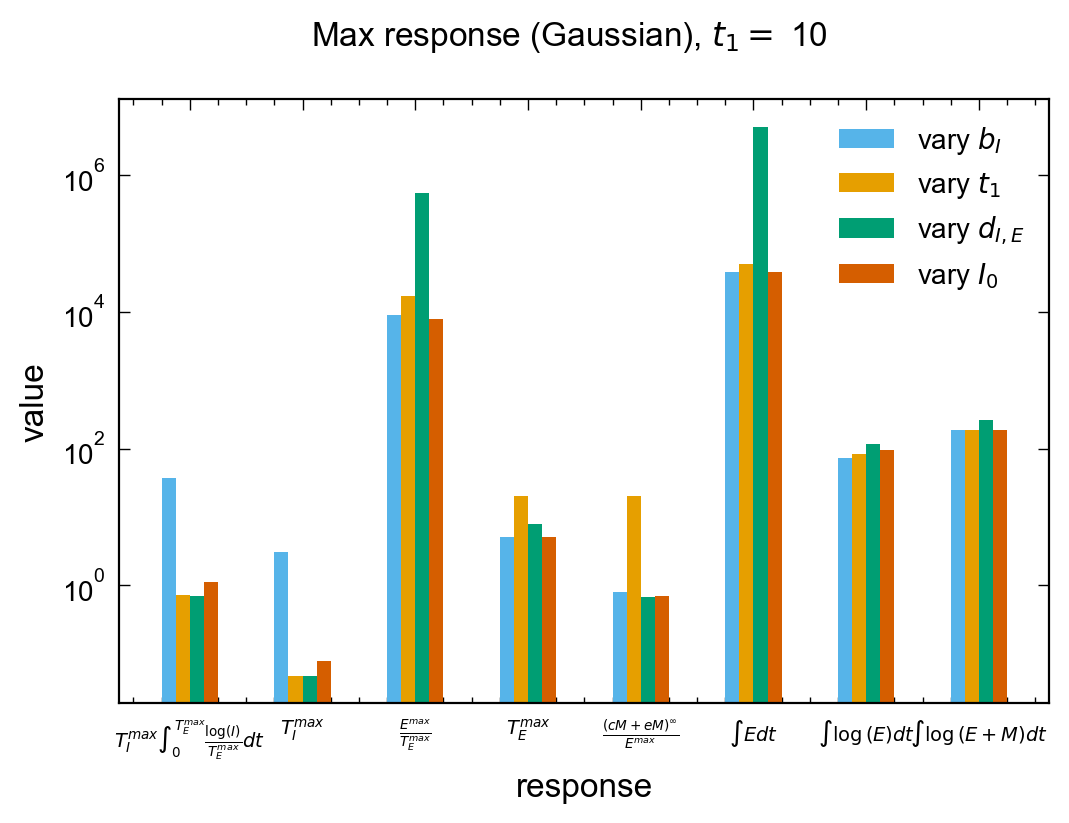

In [9]:
# Compute max values in the data
r = 2*np.arange(len(stat_names)-10)
width = 0.25
plt.bar(r, np.amax(run_data_b_I[:,10:], axis = 0), width = width, label = r'vary $b_{I}$')
plt.bar(r + width, np.amax(run_data_t1[:,10:], axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amax(run_data_d_IE[:,10:], axis = 0), width = width, label = r'vary $d_{I,E}$')
plt.bar(r + 3*width, np.amax(run_data_I_0[:,10:], axis = 0), width = width, label = r'vary $I_0$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names[10:], fontsize = 7)

plt.semilogy()
plt.legend()
plt.suptitle(r'Max response (Gaussian), $t_1=$ '+str(t1))
plt.savefig(infection_type+'-'+'response-max-gauss-t1-'+str(t1)+'.png', dpi=150)

[2.00000000e+00 8.64000000e+07 5.00000000e-01 1.00000000e+00
 6.00000000e+00 7.00000000e-02 1.00000000e+04 7.22395197e-04
 1.00000000e+01 3.80000000e-04 1.39349242e-02 6.00000000e-03
 8.93881760e+03 4.36400000e+00 1.89033300e-01 3.80767820e+04
 7.20114957e+01 1.71097443e+02]
[2.00000000e+00 8.64000000e+07 5.00000000e-01 1.00000000e+00
 6.00000000e+00 7.00000000e-02 1.00000000e+04 3.00000000e-05
 4.17294075e+01 3.80000000e-04 6.68069155e-01 4.80000000e-02
 1.70271795e+04 3.90000000e+00 2.05598892e-01 5.06807680e+04
 7.09341895e+01 1.83214871e+02]
[0.99063315 0.99486964 0.99486964 ... 0.99486964 0.99486964 0.99486964]


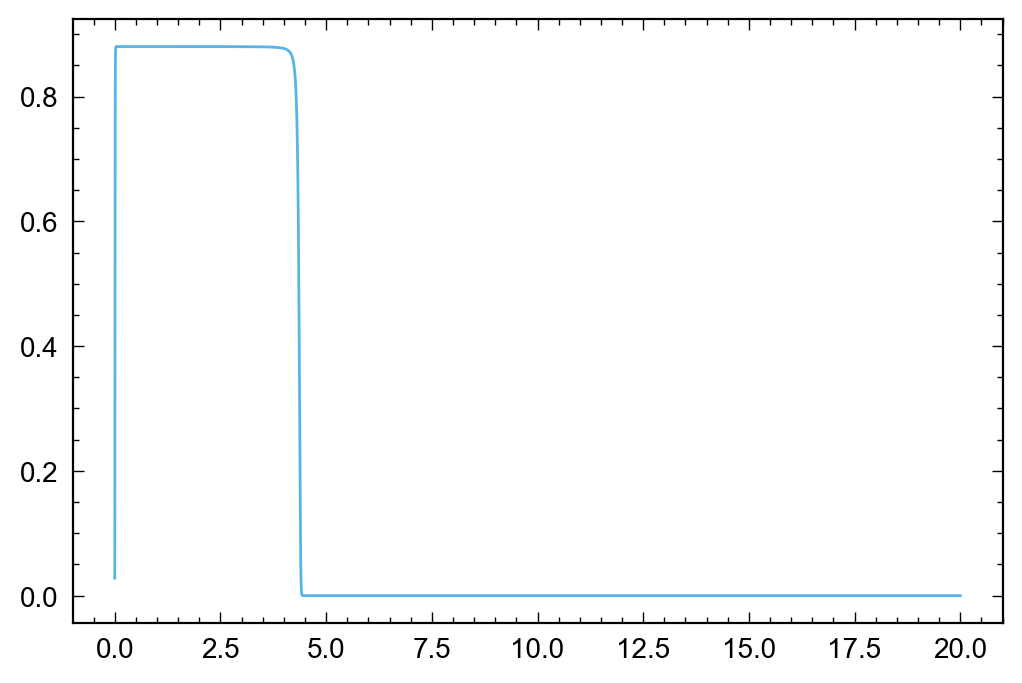

In [10]:
# Troubleshooting outliers
print(run_data_b_I[np.argmin(run_data_b_I[:, 11]),:])
print(run_data_t1[np.argmax(run_data_t1[:, 15]),:])
immune_param= (run_data_t1[np.argmax(run_data_t1[:, 15]), :])[0:6]
virus_param = (run_data_t1[np.argmax(run_data_t1[:, 15]), :])[6:10]

rates, I, N, E, cM, eM, T, ts = stoch_sim(virus_param[0], virus_param[1], virus_param[2], virus_param[3],
                                          rates = immune_param,
                                          noise_model = "pop", 
                                          noise_cv = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
                                          infection = infection_type)

#plt.plot(ts,np.array([a_stim(t1,I), a_stim(4,I)]).T)
plt.plot(ts,np.array([p_A(t1,I)]).T)
#plt.semilogy()
print(I[np.argmin(I):])

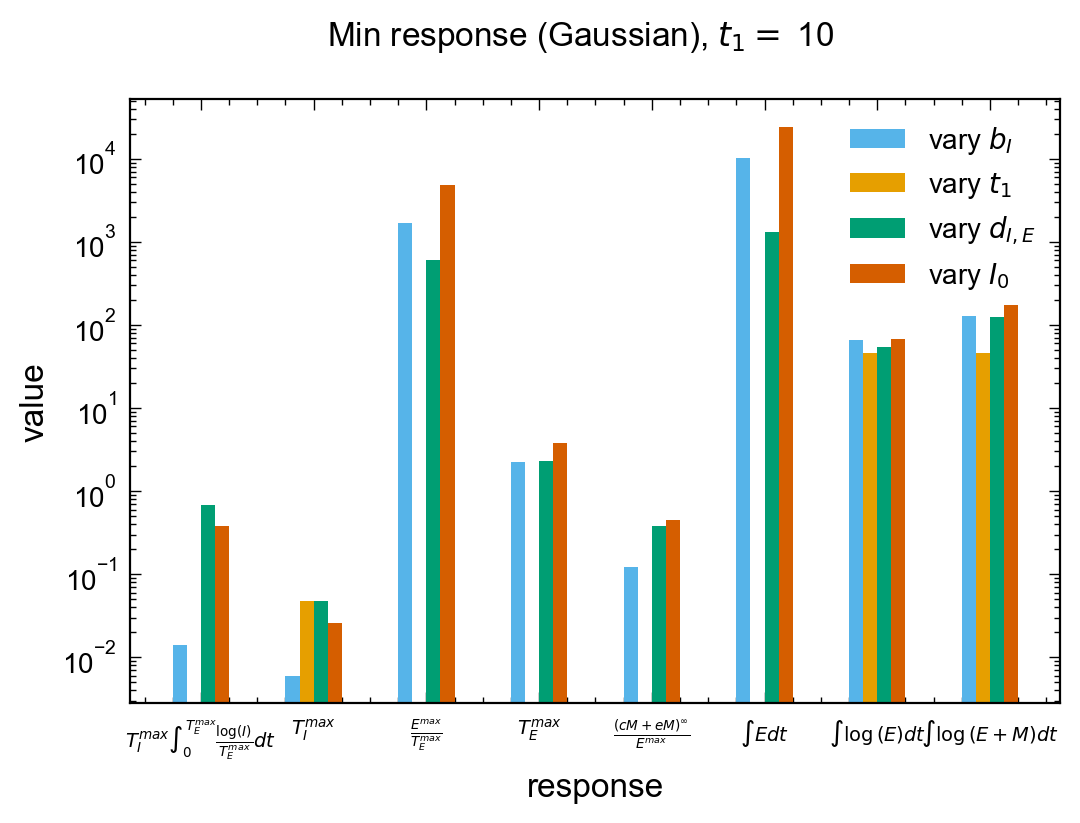

In [11]:
# Compute minimum values in the data
r = 2*np.arange(len(stat_names)-10)
width = 0.25
plt.bar(r, np.amin(run_data_b_I[:,10:], axis = 0), width = width, label = r'vary $b_{I}$')
plt.bar(r + width, np.amin(run_data_t1[:,10:], axis = 0), width = width, label = r'vary $t_1$')
plt.bar(r + 2*width, np.amin(run_data_d_IE[:,10:], axis = 0), width = width, label = r'vary $d_{I,E}$')
plt.bar(r + 3*width, np.amin(run_data_I_0[:,10:], axis = 0), width = width, label = r'vary $I_0$')

plt.xlabel("response")
plt.ylabel("value")

plt.xticks(r + 3*width/2,stat_names[10:], fontsize=7)

plt.semilogy()
plt.legend()
plt.suptitle(r'Min response (Gaussian), $t_1=$ '+str(t1))
plt.savefig(infection_type+'-'+'response-min-gauss-t1-'+str(t1)+'.png', dpi=150)

## (4) Compute mutual information between variables

In [12]:
# compute mutual information
MI_I_0 = np.zeros(run_data_I_0.shape[1])
for i in np.hstack(([6],np.arange(10,len(stat_names)))):
    MI_I_0[i] = calc_MI(run_data_I_0[:,6],run_data_I_0[:,i])  

MI_b_I = np.zeros(run_data_b_I.shape[1])
for i in np.hstack(([7],np.arange(10,len(stat_names)))):
    MI_b_I[i] = calc_MI(run_data_b_I[:,7],run_data_b_I[:,i])

MI_t1 = np.zeros(run_data_t1.shape[1])
for i in np.hstack(([8],np.arange(10,len(stat_names)))):
    MI_t1[i] = calc_MI(run_data_t1[:,8],run_data_t1[:,i])
    
MI_d_IE = np.zeros(run_data_d_IE.shape[1])
for i in np.hstack(([9],np.arange(10,len(stat_names)))):
    MI_d_IE[i] = calc_MI(run_data_d_IE[:,9],run_data_d_IE[:,i])

Text(0.5, 0.98, 'Entropy in generated data')

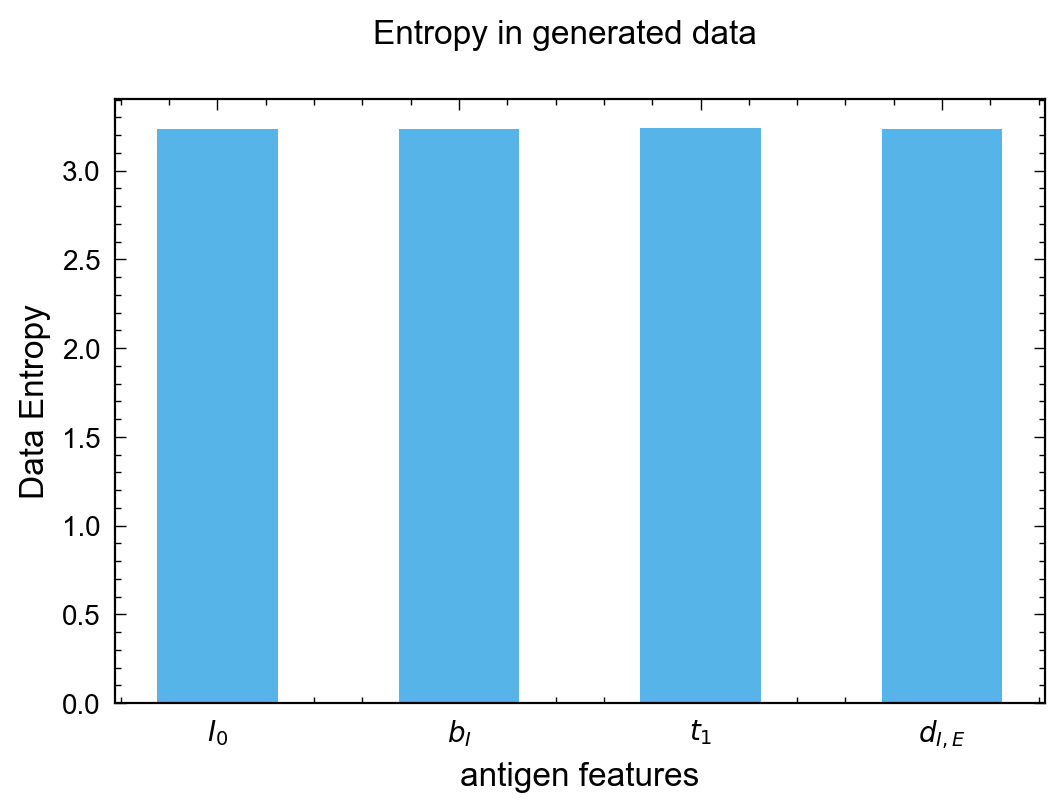

In [13]:
# Plot Data Entropy
plt.figure(1)

r = np.arange(4)
width = 0.5
plt.bar(r, np.array([MI_I_0[6],MI_b_I[7],MI_t1[8],MI_d_IE[9]]), width = width)

plt.xlabel("antigen features")
plt.ylabel("Data Entropy")

plt.xticks(r,stat_names[6:10])
plt.suptitle(r'Entropy in generated data')
#plt.savefig(infection_type+'-'+'response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150, bbox_inches="tight")

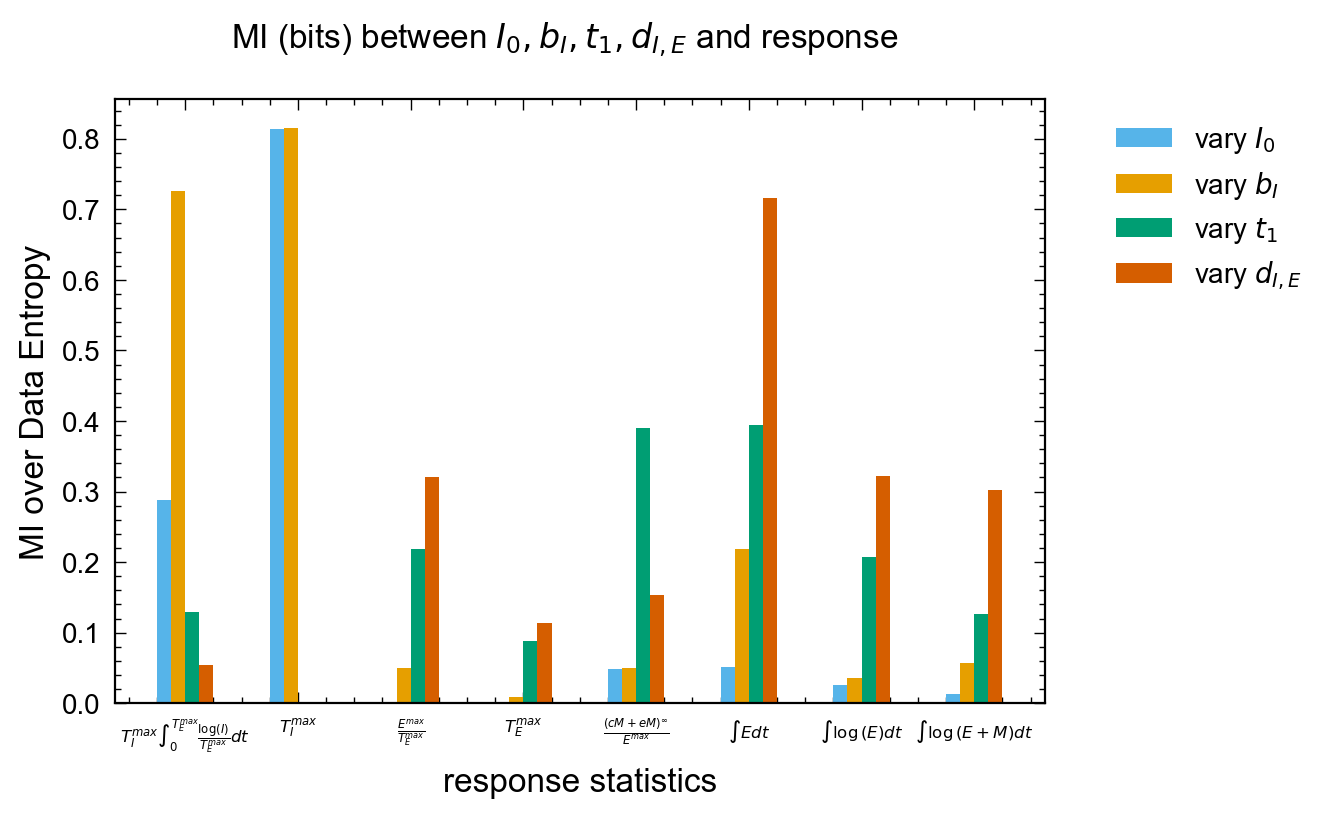

In [14]:
# Plot mutual information
plt.figure(1)

r = 2*np.arange(len(MI_b_I[10:]))
width = 0.25
plt.bar(r, MI_I_0[10:]/MI_I_0[6], width = width, label = r'vary $I_0$')
plt.bar(r + width, MI_b_I[10:]/MI_b_I[7], width = width, label = r'vary $b_{I}$')
plt.bar(r + 2*width, MI_t1[10:]/MI_t1[8], width = width, label = r'vary $t_1$')
plt.bar(r + 3*width, MI_d_IE[10:]/MI_d_IE[9], width = width, label = r'vary $d_{I,E}$')

plt.xlabel("response statistics")
plt.ylabel("MI over Data Entropy")

plt.xticks(r + 3*width/2,stat_names[10:],fontsize=6)
#plt.legend()
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.suptitle(r'MI (bits) between $I_0, b_{I}, t_1, d_{I,E}$ and response')
plt.savefig(infection_type+'-'+'response-mutual-info-gauss-t1-'+str(t1)+'.png', dpi=150, bbox_inches="tight")

## (5) Plot trajectories from simulations

In [15]:
# Plot trajectories for b_I

# fig_b_I.suptitle(r'Immune response varying $b_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_b_I.savefig('plot-response-varying-b_I-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[7]]*len(ylabels)

fig_b_I = joint_plot_grid([run_data_b_I[:,7]]* len(ylabels), run_data_b_I[:,10:].T.tolist(), granularity=50,
                use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_b_I.savefig(infection_type+'-'+'plot-response-varying-b_I-gauss-t1-'+str(t1)+'.png', dpi=150,bbox_inches="tight")


/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


In [16]:
# Plot trajectories for t1
# fig_t1.suptitle(r'Immune response while varying $t_1$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-t1-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[8]]*len(ylabels)

fig_t1 = joint_plot_grid([run_data_t1[:,8]]*len(ylabels), run_data_t1[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_t1.savefig(infection_type+'-'+'plot-response-varying-t1-gauss-t1-'+str(t1)+'.png', dpi=150)

/opt/anaconda3/lib/python3.9/site-packages/mpl_scatter_density/scatter_density_axes.py:49: UserWarning: Attempting to set identical bottom == top == 0.048 results in singular transformations; automatically expanding.
  self.set_ylim(np.min(y), np.max(y))


In [17]:
# Plot trajectories for d_IE
# fig_t1.suptitle(r'Immune response while varying $d_{a_1}$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-d_IE-gauss-t1-'+str(t1)+'.png', dpi=150)

ylabels=stat_names[10:]
xlabels = [stat_names[9]]*len(ylabels)

fig_d_IE = joint_plot_grid([run_data_d_IE[:,9]]*len(ylabels), run_data_d_IE[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)
fig_d_IE.savefig(infection_type+'-'+'plot-response-varying-d_IE-gauss-t1-'+str(t1)+'.png', dpi=150)

In [18]:
# Plot trajectories for I_0
# fig_t1.suptitle(r'Immune response while varying $a_1^0$ (Gaussian), $t_1=$ '+str(t1))
# plt.show()
# fig_t1.savefig('plot-response-varying-I_0-gauss-t1-'+str(t1)+'.png', dpi=150)
ylabels=stat_names[10:]
xlabels = [stat_names[6]]*len(ylabels)

fig_I_0 = joint_plot_grid([run_data_I_0[:,6]]*len(ylabels), run_data_I_0[:,10:].T.tolist(), granularity=50, use_mpl_sd=True
               ,xlabels  = xlabels, ylabels = ylabels)

fig_I_0.savefig(infection_type+'-'+'plot-response-varying-I_0-gauss-t1-'+str(t1)+'.png', dpi=150)
